In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/jaipur.csv.zip", encoding="latin-1")
print(df.sample(5))
print("rows and columns: ",df.shape)

                 date_time  maxtempC  mintempC  totalSnow_cm  sunHour  \
22594  2011-07-31 10:00:00        36        27           0.0     13.7   
81529  2018-04-21 01:00:00        37        24           0.0     13.0   
55854  2015-05-17 06:00:00        43        29           0.0     13.7   
33477  2012-10-26 21:00:00        30        18           0.0      8.7   
45446  2014-03-09 14:00:00        30        17           0.0     11.6   

       uvIndex  uvIndex.1  moon_illumination  moonrise     moonset  ...  \
22594        8          8                  0  06:14 AM    07:33 PM  ...   
81529        8          1                 39  10:23 AM  No moonset  ...   
55854        9          8                  0  04:58 AM    06:21 PM  ...   
33477        6          1                 75  03:37 PM    03:18 AM  ...   
45446        6          7                 53  12:25 PM    01:23 AM  ...   

      WindChillC WindGustKmph  cloudcover  humidity  precipMM  pressure  \
22594         35           11      

In [2]:
print(df.info)

<bound method DataFrame.info of                  date_time  maxtempC  mintempC  totalSnow_cm  sunHour  \
0      2009-01-01 00:00:00        24         8           0.0      8.7   
1      2009-01-01 01:00:00        24         8           0.0      8.7   
2      2009-01-01 02:00:00        24         8           0.0      8.7   
3      2009-01-01 03:00:00        24         8           0.0      8.7   
4      2009-01-01 04:00:00        24         8           0.0      8.7   
...                    ...       ...       ...           ...      ...   
96427  2020-01-01 19:00:00        19         8           0.0      8.7   
96428  2020-01-01 20:00:00        19         8           0.0      8.7   
96429  2020-01-01 21:00:00        19         8           0.0      8.7   
96430  2020-01-01 22:00:00        19         8           0.0      8.7   
96431  2020-01-01 23:00:00        19         8           0.0      8.7   

       uvIndex  uvIndex.1  moon_illumination  moonrise   moonset  ...  \
0            4    

In [3]:
print("Summary :")
print(df.describe())

Summary :
           maxtempC      mintempC  totalSnow_cm       sunHour       uvIndex  \
count  96432.000000  96432.000000       96432.0  96432.000000  96432.000000   
mean      32.788701     21.469886           0.0     11.234769      6.776506   
std        6.602928      7.482104           0.0      1.999857      1.500904   
min       15.000000      3.000000           0.0      3.900000      3.000000   
25%       28.000000     15.000000           0.0      8.700000      6.000000   
50%       33.000000     23.000000           0.0     11.600000      7.000000   
75%       37.000000     27.000000           0.0     13.300000      8.000000   
max       48.000000     36.000000           0.0     13.900000     10.000000   

          uvIndex.1  moon_illumination     DewPointC    FeelsLikeC  \
count  96432.000000       96432.000000  96432.000000  96432.000000   
mean       4.656711          46.094077      9.496474     28.293896   
std        3.320682          31.249725      8.676747      8.543340  

In [4]:
print("null values: ",df.isna().sum())
print("duplicates: ",df.duplicated().sum())

null values:  date_time            0
maxtempC             0
mintempC             0
totalSnow_cm         0
sunHour              0
uvIndex              0
uvIndex.1            0
moon_illumination    0
moonrise             0
moonset              0
sunrise              0
sunset               0
DewPointC            0
FeelsLikeC           0
HeatIndexC           0
WindChillC           0
WindGustKmph         0
cloudcover           0
humidity             0
precipMM             0
pressure             0
tempC                0
visibility           0
winddirDegree        0
windspeedKmph        0
dtype: int64
duplicates:  0


In [5]:
# define heatwave condition and treating it as our output column
conditions = [
    (df['HeatIndexC'] < 40),                                     # Low
    (df['HeatIndexC'] >= 40) & (df['HeatIndexC'] < 45),          # Mild
    (df['HeatIndexC'] >= 45)                                     # Extreme
]

choices = [0, 1, 2]

df['heatwave_category'] = np.select(conditions, choices, default=0)

print(df['heatwave_category'].value_counts(normalize=True) * 100)

heatwave_category
0    91.567115
1     6.921976
2     1.510909
Name: proportion, dtype: float64


In [6]:
print(df.columns)

Index(['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour',
       'uvIndex', 'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset',
       'sunrise', 'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC',
       'WindChillC', 'WindGustKmph', 'cloudcover', 'humidity', 'precipMM',
       'pressure', 'tempC', 'visibility', 'winddirDegree', 'windspeedKmph',
       'heatwave_category'],
      dtype='object')


Univariate analysis

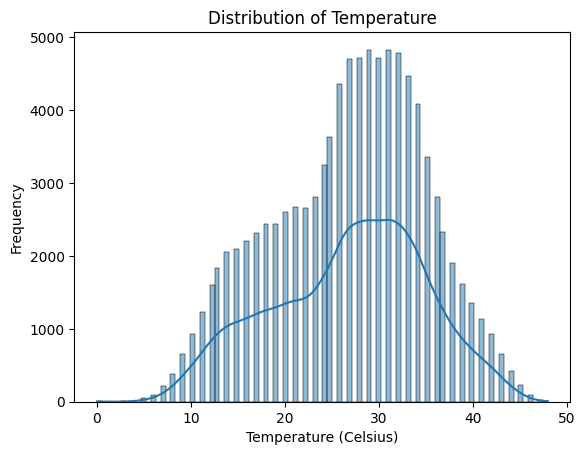

In [7]:
sns.histplot(data=df,x=df['tempC'],kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency')
plt.show()

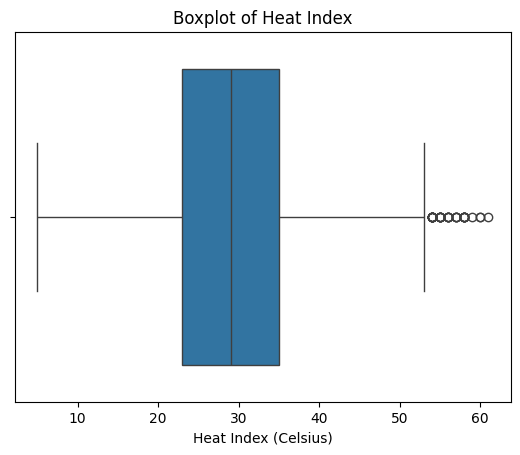

In [8]:
sns.boxplot(data=df,x=df['HeatIndexC'])
plt.title('Boxplot of Heat Index')
plt.xlabel('Heat Index (Celsius)')
plt.show()

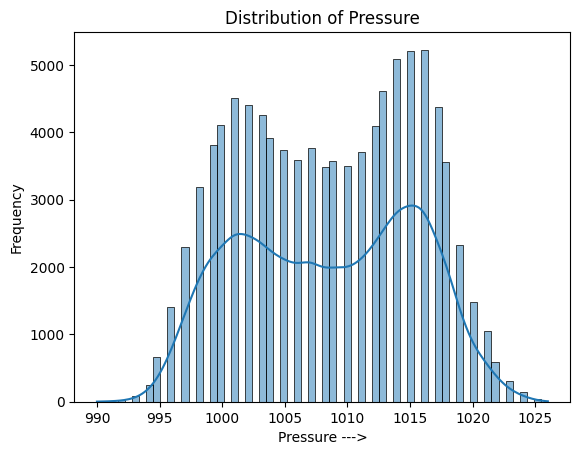

In [9]:
sns.histplot(data=df,x=df['pressure'],kde=True)
plt.title('Distribution of Pressure')
plt.xlabel('Pressure --->')
plt.ylabel('Frequency')
plt.show()

In [10]:
df['date_time'] = pd.to_datetime(df['date_time'])
df["hours"] = df["date_time"].dt.hour
df["month"] = df["date_time"].dt.month_name()

print(df.columns)

Index(['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour',
       'uvIndex', 'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset',
       'sunrise', 'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC',
       'WindChillC', 'WindGustKmph', 'cloudcover', 'humidity', 'precipMM',
       'pressure', 'tempC', 'visibility', 'winddirDegree', 'windspeedKmph',
       'heatwave_category', 'hours', 'month'],
      dtype='object')


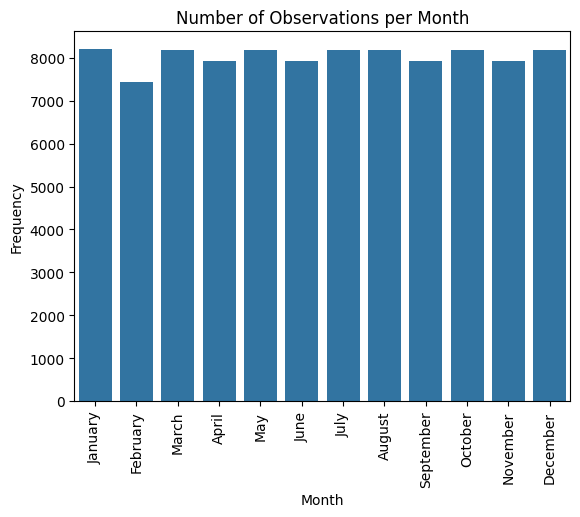

In [11]:
sns.countplot(x=df['month'])
plt.title('Number of Observations per Month')
plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

Bivariate Analysis

In [12]:
Correlation=df.corr(numeric_only=True)['heatwave_category']
print("Top Positive correlation ------> ")
print(Correlation[Correlation>0].sort_values(ascending=False))
print("Top Negative correlation ------> ")
print(Correlation[Correlation<0].sort_values())

Top Positive correlation ------> 
heatwave_category    1.000000
HeatIndexC           0.502329
FeelsLikeC           0.497763
WindChillC           0.472958
tempC                0.469989
uvIndex.1            0.404204
maxtempC             0.383007
uvIndex              0.358344
mintempC             0.326649
sunHour              0.325085
windspeedKmph        0.174898
winddirDegree        0.133842
hours                0.041874
DewPointC            0.023460
visibility           0.021067
WindGustKmph         0.014435
Name: heatwave_category, dtype: float64
Top Negative correlation ------> 
pressure            -0.343075
humidity            -0.243320
precipMM            -0.016392
cloudcover          -0.014572
moon_illumination   -0.009454
Name: heatwave_category, dtype: float64


/tmp/ipykernel_467/3416866336.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df.groupby(['month', 'heatwave_category']).size().unstack().plot(kind='bar', stacked=True, figsize=(12, 6))


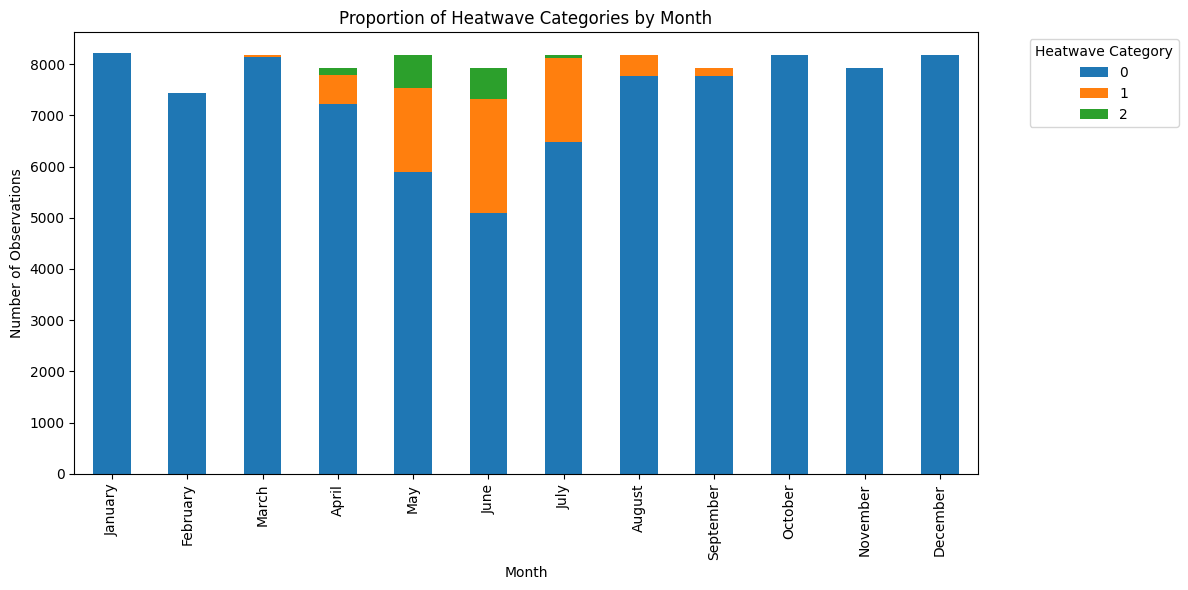

In [13]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['month'] = pd.Categorical(df['month'], categories=months_order, ordered=True)
df = df.sort_values('month')
ax = df.groupby(['month', 'heatwave_category']).size().unstack().plot(kind='bar', stacked=True, figsize=(12, 6))
ax.legend(title='Heatwave Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Observations')
ax.set_title('Proportion of Heatwave Categories by Month')
plt.tight_layout()
plt.show()

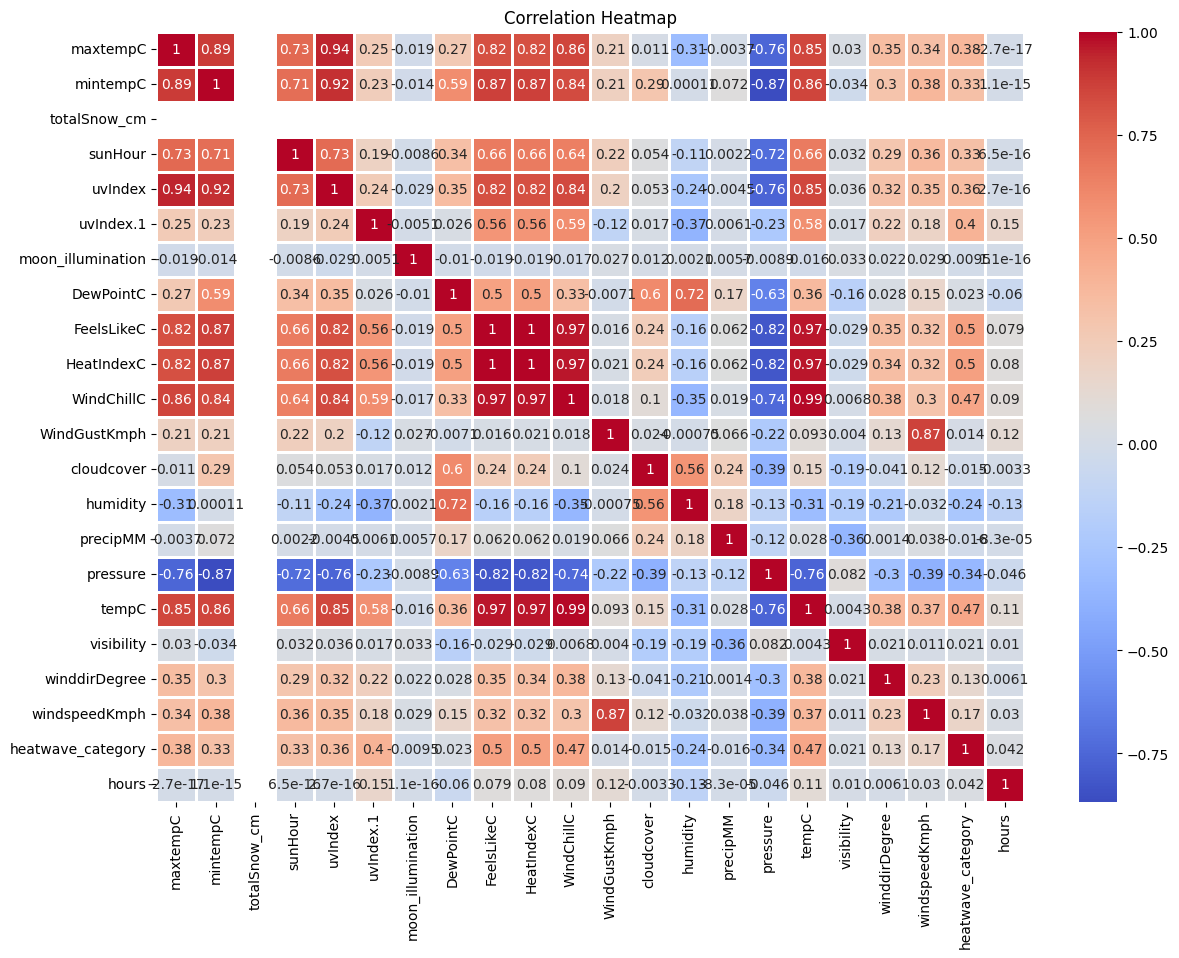

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm',linewidths=0.8)
plt.title('Correlation Heatmap')
plt.show()

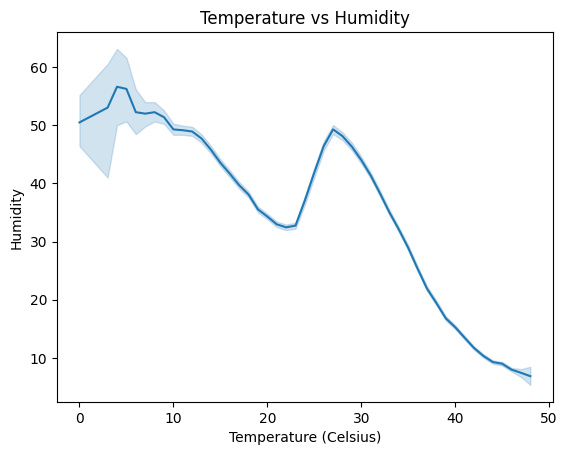

In [15]:
sns.lineplot(data=df,x=df['tempC'],y=df['humidity'])
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Humidity')
plt.show()

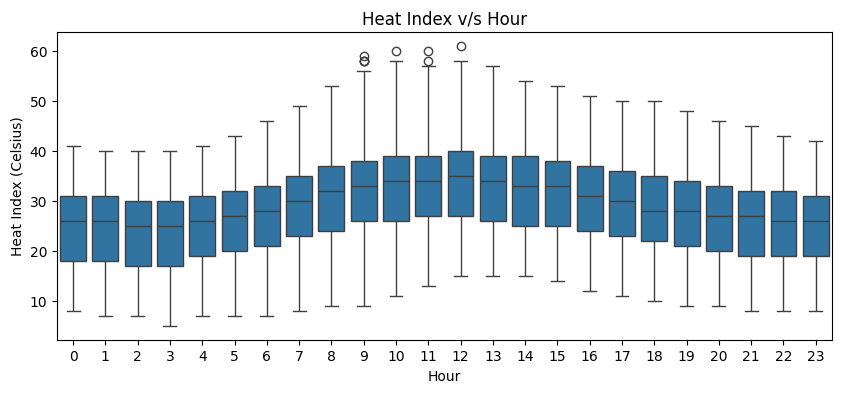

In [16]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df,x=df['hours'],y=df['HeatIndexC'])
plt.title('Heat Index v/s Hour')
plt.xlabel('Hour')
plt.ylabel('Heat Index (Celsius)')
plt.show()

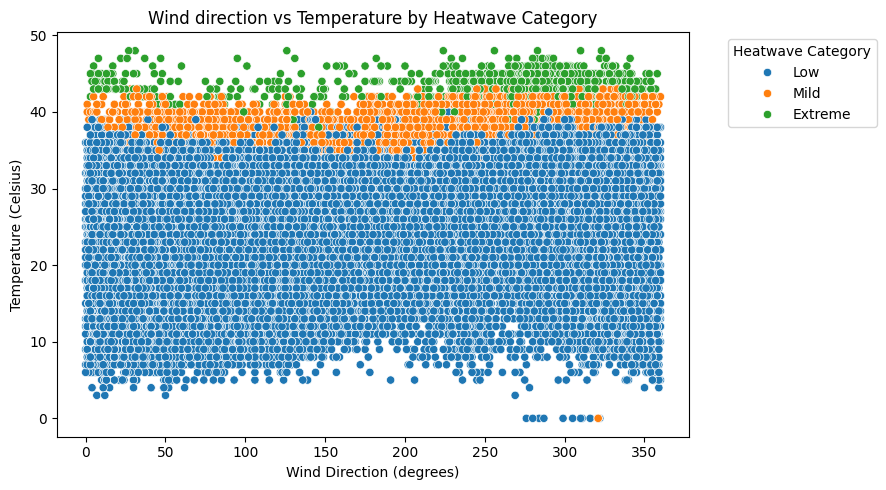

In [17]:
df['heatwave_category']=df['heatwave_category'].map({0:'Low',1:'Mild',2:'Extreme'})
plt.figure(figsize=(9,5))
sns.scatterplot(data=df,x=df['winddirDegree'],y=df['tempC'],hue=df['heatwave_category'])
plt.title('Wind direction vs Temperature by Heatwave Category')
plt.xlabel('Wind Direction (degrees)')
plt.ylabel('Temperature (Celsius)')
plt.legend(title='Heatwave Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

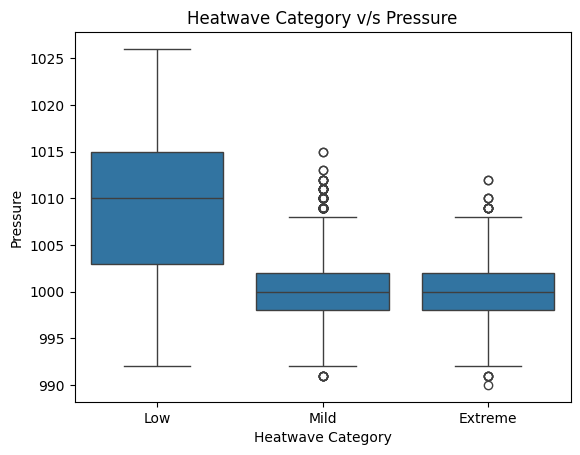

In [18]:
sns.boxplot(data=df,x=df['heatwave_category'],y=df['pressure'])
plt.title('Heatwave Category v/s Pressure')
plt.xlabel('Heatwave Category')
plt.ylabel('Pressure')
plt.show()

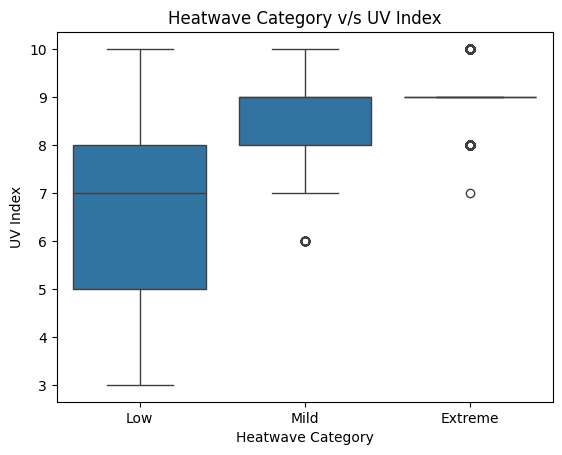

In [19]:
sns.boxplot(data=df,x=df['heatwave_category'],y=df['uvIndex'])
plt.title('Heatwave Category v/s UV Index')
plt.xlabel('Heatwave Category')
plt.ylabel('UV Index')
plt.show()

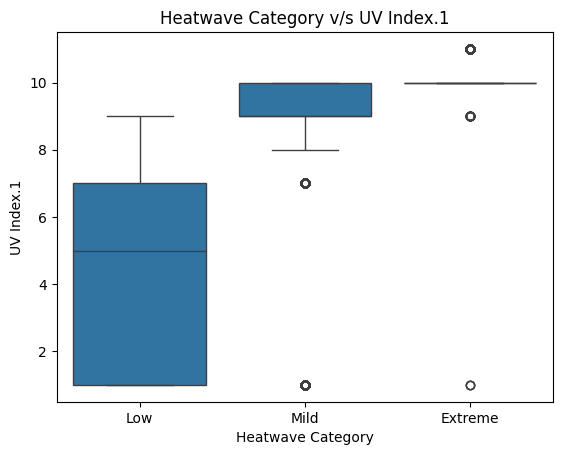

In [20]:
sns.boxplot(data=df,x=df['heatwave_category'],y=df['uvIndex.1'])
plt.title('Heatwave Category v/s UV Index.1')
plt.xlabel('Heatwave Category')
plt.ylabel('UV Index.1')
plt.show()

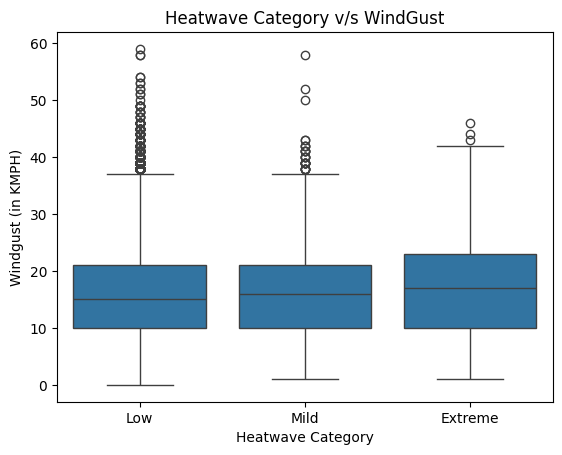

In [21]:
sns.boxplot(data=df,x=df['heatwave_category'],y=df['WindGustKmph'])
plt.title('Heatwave Category v/s WindGust')
plt.xlabel('Heatwave Category')
plt.ylabel('Windgust (in KMPH)')
plt.show()

Removing Irrelevant Columns

In [22]:
drop_columns= ['totalSnow_cm','uvIndex.1', 'moon_illumination', 'moonrise', 'moonset',
       'sunrise', 'sunset', 'FeelsLikeC', 'HeatIndexC',
       'WindChillC']
df = df.drop(columns=drop_columns)
print("Remaining columns :")
print(df.columns)

Remaining columns :
Index(['date_time', 'maxtempC', 'mintempC', 'sunHour', 'uvIndex', 'DewPointC',
       'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure',
       'tempC', 'visibility', 'winddirDegree', 'windspeedKmph',
       'heatwave_category', 'hours', 'month'],
      dtype='object')


Feature Engineering

In [23]:
# sort date-time
df = df.sort_values('date_time').reset_index(drop=True)

# cyclical encoding hours
df["hour_sin"] = np.sin(2*np.pi*df["hours"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hours"]/24)

month_numbers = df['date_time'].dt.month
# cyclical encoding months
df['month_sin'] = np.sin(2 * np.pi * month_numbers/12)
df['month_cos'] = np.cos(2 * np.pi * month_numbers/12)

# Lags
df['temp_lag1hr'] = df['tempC'].shift(1)
df['temp_lag3hr'] = df['tempC'].shift(3)

df['pressure_lag1hr'] = df['pressure'].shift(1)
df['pressure_lag3hr'] = df['pressure'].shift(3)

# rolling stats
df['temp_rolling24hr']=df['tempC'].rolling(window=24).mean()
df['temp_rolling48hr']=df['tempC'].rolling(window=48).mean()
df['temp_rolling72hr']=df['tempC'].rolling(window=72).mean()

df['pressure_rolling24hr']=df['pressure'].rolling(window=24).mean()
df['pressure_rolling48hr']=df['pressure'].rolling(window=48).mean()
df['pressure_rolling72hr']=df['pressure'].rolling(window=72).mean()

df['humidity_rolling24hr']=df['humidity'].rolling(window=24).mean()
df['humidity_rolling48hr']=df['humidity'].rolling(window=48).mean()

# rolling stats Extreme
df['temp_max_24hr']=df['tempC'].rolling(window=24).max()
df['temp_max_48hr']=df['tempC'].rolling(window=48).max()
df['temp_max_72hr']=df['tempC'].rolling(window=72).max()

df['temp_min_24hr']=df['tempC'].rolling(window=24).min()
df['temp_min_48hr']=df['tempC'].rolling(window=48).min()
df['temp_min_72hr']=df['tempC'].rolling(window=72).min()

# Diurnal Temperature Range
df['temp_range_24hr']=df['temp_max_24hr']-df['temp_min_24hr']

# drop original hours and month columns
df.drop(columns=['hours','month'])

df = df.dropna().reset_index(drop=True)

In [24]:
print(df.columns)

Index(['date_time', 'maxtempC', 'mintempC', 'sunHour', 'uvIndex', 'DewPointC',
       'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure',
       'tempC', 'visibility', 'winddirDegree', 'windspeedKmph',
       'heatwave_category', 'hours', 'month', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'temp_lag1hr', 'temp_lag3hr',
       'pressure_lag1hr', 'pressure_lag3hr', 'temp_rolling24hr',
       'temp_rolling48hr', 'temp_rolling72hr', 'pressure_rolling24hr',
       'pressure_rolling48hr', 'pressure_rolling72hr', 'humidity_rolling24hr',
       'humidity_rolling48hr', 'temp_max_24hr', 'temp_max_48hr',
       'temp_max_72hr', 'temp_min_24hr', 'temp_min_48hr', 'temp_min_72hr',
       'temp_range_24hr'],
      dtype='object')


Chronological Splitting of the data

In [25]:
df['year'] = df['date_time'].dt.year

train_df = df[df['year'] <= 2017].copy()

valid_df = df[df['year'] == 2018].copy()

test_df = df[df['year'] >= 2019].copy()

columns_to_drop = ['year', 'date_time','month']

X_train = train_df.drop(columns=columns_to_drop + ['heatwave_category'])
y_train = train_df['heatwave_category']

X_valid = valid_df.drop(columns=columns_to_drop + ['heatwave_category'])
y_valid = valid_df['heatwave_category']

X_test = test_df.drop(columns=columns_to_drop + ['heatwave_category'])
y_test = test_df['heatwave_category']

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_valid.shape}, y={y_valid.shape}")
print(f"Testing shapes: X={X_test.shape}, y={y_test.shape}")

Training shapes: X=(78817, 38), y=(78817,)
Validation shapes: X=(8760, 38), y=(8760,)
Testing shapes: X=(8784, 38), y=(8784,)


Base Model - random forest

Classification Report on Validation Data:
              precision    recall  f1-score   support

     Extreme       0.90      0.87      0.88       157
         Low       0.99      0.99      0.99      7974
        Mild       0.88      0.82      0.85       629

    accuracy                           0.98      8760
   macro avg       0.92      0.89      0.91      8760
weighted avg       0.98      0.98      0.98      8760



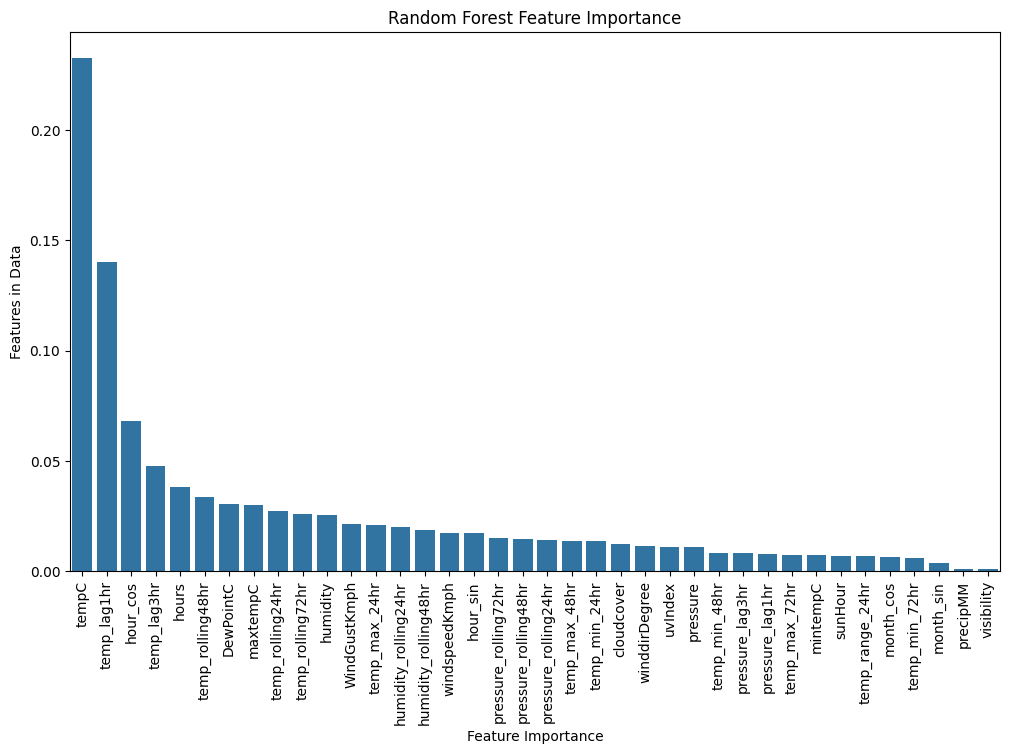

Irrelevant Features (Last 5):
month_cos        0.006192
temp_min_72hr    0.006006
month_sin        0.003794
precipMM         0.000734
visibility       0.000672
dtype: float64


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# prediction on Validation data
y_val_pred = rf.predict(X_valid)

print("Classification Report on Validation Data:")
print(classification_report(y_valid, y_val_pred))

# Feature importance plotting
importances = rf.feature_importances_
feature_names = X_train.columns

feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_imp.index, y=feature_imp)
plt.xlabel('Feature Importance')
plt.ylabel('Features in Data')
plt.xticks(rotation=90)
plt.title('Random Forest Feature Importance')
plt.show()

print("Irrelevant Features (Last 5):")
print(feature_imp.tail(5))

In [27]:
useless_features = ['visibility','precipMM','month_sin','month_cos','temp_min_72hr',
                    'temp_min_48hr','uvIndex','sunHour']

X_train_new = X_train.drop(columns=useless_features)
X_valid_new = X_valid.drop(columns=useless_features)
X_test_new = X_test.drop(columns=useless_features)

In [28]:
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_new, y_train)

# prediction on Validation data
y_val_pred2 = rf2.predict(X_valid_new)

print("Classification Report on Validation Data:")
print(classification_report(y_valid, y_val_pred2))

Classification Report on Validation Data:
              precision    recall  f1-score   support

     Extreme       0.91      0.84      0.87       157
         Low       0.99      0.99      0.99      7974
        Mild       0.88      0.82      0.85       629

    accuracy                           0.98      8760
   macro avg       0.92      0.89      0.90      8760
weighted avg       0.98      0.98      0.98      8760



In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_valid_encoded = le.transform(y_valid)
y_test_encoded = le.transform(y_test)

print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class Mapping: {'Extreme': np.int64(0), 'Low': np.int64(1), 'Mild': np.int64(2)}


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score


def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["RandomForest", "XGBoost", "LightGBM", "CatBoost"])

    if classifier_name == "RandomForest":
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
        max_depth = trial.suggest_int("rf_max_depth", 5, 30)
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)

    elif classifier_name == "XGBoost":
        n_estimators = trial.suggest_int("xgb_n_estimators", 50, 300)
        max_depth = trial.suggest_int("xgb_max_depth", 3, 10)
        learning_rate = trial.suggest_float("xgb_lr", 1e-3, 0.3, log=True)
        model = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=42, n_jobs=-1)

    elif classifier_name == "LightGBM":
        n_estimators = trial.suggest_int("lgb_n_estimators", 50, 300)
        max_depth = trial.suggest_int("lgb_max_depth", 3, 12)
        learning_rate = trial.suggest_float("lgb_lr", 1e-3, 0.3, log=True)
        model = LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=42, n_jobs=-1, verbose=-1)

    elif classifier_name == "CatBoost":
        iterations = trial.suggest_int("cat_iterations", 50, 300)
        depth = trial.suggest_int("cat_depth", 3, 10)
        learning_rate = trial.suggest_float("cat_lr", 1e-3, 0.3, log=True)
        model = CatBoostClassifier(iterations=iterations, depth=depth, learning_rate=learning_rate, random_state=42, verbose=0)

    model.fit(X_train_new, y_train_encoded)
    y_pred = model.predict(X_valid_new)
    score = f1_score(y_valid_encoded, y_pred, average='macro')

    return score

study = optuna.create_study(direction="maximize")
print("Starting Optuna Study...")
study.optimize(objective, n_trials=30)

print("\n--- Best Trial ---")
print(f"Best Macro F1-Score: {study.best_value}")
print("Best Model & Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


[I 2026-08-12 08:59:19,346] A new study created in memory with name: no-name-8600194f-65bc-4c89-961a-12ed321b1ca2


Starting Optuna Study...


[I 2026-08-12 09:00:20,034] Trial 0 finished with value: 0.9237383371660338 and parameters: {'classifier': 'CatBoost', 'cat_iterations': 182, 'cat_depth': 10, 'cat_lr': 0.056519848693986054}. Best is trial 0 with value: 0.9237383371660338.
[I 2026-08-12 09:00:46,154] Trial 1 finished with value: 0.9014848087289695 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 212, 'rf_max_depth': 14}. Best is trial 0 with value: 0.9237383371660338.
[I 2026-08-12 09:00:51,014] Trial 2 finished with value: 0.9317712147942673 and parameters: {'classifier': 'LightGBM', 'lgb_n_estimators': 89, 'lgb_max_depth': 6, 'lgb_lr': 0.02216818521863291}. Best is trial 2 with value: 0.9317712147942673.
[I 2026-08-12 09:00:56,473] Trial 3 finished with value: 0.9018440087849827 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 51, 'rf_max_depth': 12}. Best is trial 2 with value: 0.9317712147942673.
[I 2026-08-12 09:01:06,804] Trial 4 finished with value: 0.9095017212901374 and parame


--- Best Trial ---
Best Macro F1-Score: 0.9459473505149468
Best Model & Hyperparameters:
  classifier: XGBoost
  xgb_n_estimators: 241
  xgb_max_depth: 7
  xgb_lr: 0.040843505134372744


In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_final = XGBClassifier(n_estimators=241, max_depth=7, learning_rate=0.040843505134372744,
                          random_state=42, n_jobs=-1)

print("Training final Model :")
xgb_final.fit(X_train_new, y_train_encoded)

# prediction on Validation data
y_val_pred_final = xgb_final.predict(X_valid_new)

print("Final Classification Report on Validation data: ")
print(classification_report(y_valid_encoded, y_val_pred_final, target_names=le.classes_))

Training final Model :
Final Classification Report on Validation data: 
              precision    recall  f1-score   support

     Extreme       0.93      0.92      0.93       157
         Low       0.99      1.00      0.99      7974
        Mild       0.93      0.91      0.92       629

    accuracy                           0.99      8760
   macro avg       0.95      0.94      0.95      8760
weighted avg       0.99      0.99      0.99      8760



In [ ]:
# testing the model on TEST DATA
y_test_pred_final = xgb_final.predict(X_test_new)

print("Final Classification Report on Test data: ")
print(classification_report(y_test_encoded, y_test_pred_final, target_names=le.classes_))

Final Classification Report on Test data: 
              precision    recall  f1-score   support

     Extreme       0.86      0.97      0.91       116
         Low       0.99      0.99      0.99      8012
        Mild       0.83      0.86      0.85       656

    accuracy                           0.98      8784
   macro avg       0.89      0.94      0.92      8784
weighted avg       0.98      0.98      0.98      8784



In [34]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class TemporalFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, window_size=72):
        self.window_size = window_size
        self.history_buffer = None

        # Useless Features
        self.useless_features = [
            'visibility', 'precipMM', 'uvIndex', 'sunHour'
        ]

    def fit(self, X, y=None):
        # Store last 72 hours of the training data
        self.history_buffer = X.tail(self.window_size).copy()
        return self

    def transform(self, X):
        X_copy = X.copy()

        if self.history_buffer is not None:
            combined = pd.concat([self.history_buffer, X_copy], ignore_index=True)
        else:
            combined = X_copy

        # datetime formatting
        combined['date_time'] = pd.to_datetime(combined['date_time'])
        if 'hours' not in combined.columns:
            combined['hours'] = combined['date_time'].dt.hour

        # Cyclical Encoding
        combined['hour_sin'] = np.sin(2 * np.pi * combined['hours'] / 24)
        combined['hour_cos'] = np.cos(2 * np.pi * combined['hours'] / 24)

        # Time-Series Lags
        combined['temp_lag1hr'] = combined['tempC'].shift(1)
        combined['temp_lag3hr'] = combined['tempC'].shift(3)
        combined['pressure_lag1hr'] = combined['pressure'].shift(1)
        combined['pressure_lag3hr'] = combined['pressure'].shift(3)

        # Rolling Stats
        combined['temp_rolling24hr'] = combined['tempC'].rolling(window=24, min_periods=1).mean()
        combined['temp_rolling48hr'] = combined['tempC'].rolling(window=48, min_periods=1).mean()
        combined['temp_rolling72hr'] = combined['tempC'].rolling(window=72, min_periods=1).mean()

        combined['pressure_rolling24hr'] = combined['pressure'].rolling(window=24, min_periods=1).mean()
        combined['pressure_rolling48hr'] = combined['pressure'].rolling(window=48, min_periods=1).mean()
        combined['pressure_rolling72hr'] = combined['pressure'].rolling(window=72, min_periods=1).mean()

        combined['humidity_rolling24hr'] = combined['humidity'].rolling(window=24, min_periods=1).mean()
        combined['humidity_rolling48hr'] = combined['humidity'].rolling(window=48, min_periods=1).mean()

        # Rolling Extreme & Diurnal Range
        combined['temp_max_24hr'] = combined['tempC'].rolling(window=24, min_periods=1).max()
        combined['temp_max_48hr'] = combined['tempC'].rolling(window=48, min_periods=1).max()
        combined['temp_max_72hr'] = combined['tempC'].rolling(window=72, min_periods=1).max()

        combined['temp_min_24hr'] = combined['tempC'].rolling(window=24, min_periods=1).min()
        combined['temp_range_24hr'] = combined['temp_max_24hr'] - combined['temp_min_24hr']

        # Cleanup Useless and Raw Columns
        columns_to_drop = self.useless_features + ['date_time', 'month', 'year']
        combined = combined.drop(columns=columns_to_drop, errors='ignore')

        output = combined.tail(len(X_copy)).copy()
        if self.history_buffer is not None:
             new_buffer = pd.concat([self.history_buffer, X_copy], ignore_index=True)
             self.history_buffer = new_buffer.tail(self.window_size).copy()

        return output

In [35]:
# Raw inputs before manual feature engineering
X_train_raw = train_df.drop(columns=['heatwave_category', 'year'], errors='ignore')
X_valid_raw   = valid_df.drop(columns=['heatwave_category', 'year'], errors='ignore')
X_test_raw  = test_df.drop(columns=['heatwave_category', 'year'], errors='ignore')

In [36]:
import joblib
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_champion = XGBClassifier(
    n_estimators=241,
    max_depth=7,
    learning_rate=0.040843505134372744,
    random_state=42,
    n_jobs=-1
)

# Construct the Pipeline
heatwave_pipeline = Pipeline([
    ('feature_engineer', TemporalFeatureEngineer(window_size=72)),
    ('classifier', xgb_champion)
])

# Fit the Pipeline on Raw Training Data
print("Fitting end-to-end pipeline...")
heatwave_pipeline.fit(X_train_raw, y_train_encoded)

print("Evaluating pipeline on unseen test data...")
y_test_pred_pipeline = heatwave_pipeline.predict(X_test_raw)

print("\n--- Pipeline Test Performance ---")
print(classification_report(y_test_encoded, y_test_pred_pipeline, target_names=le.classes_))

# Save the Full Pipeline for Deployment
joblib.dump(heatwave_pipeline, 'urban_heatwave_pipeline.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\nSuccess! Pipeline saved as 'urban_heatwave_pipeline.pkl'")

Fitting end-to-end pipeline...
Evaluating pipeline on unseen test data...

--- Pipeline Test Performance ---
              precision    recall  f1-score   support

     Extreme       0.86      0.97      0.91       116
         Low       0.99      0.99      0.99      8012
        Mild       0.83      0.85      0.84       656

    accuracy                           0.98      8784
   macro avg       0.89      0.94      0.91      8784
weighted avg       0.98      0.98      0.98      8784


Success! Pipeline saved as 'urban_heatwave_pipeline.pkl'
